In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/labeled-chest-xray-images/chest_xray/test/PNEUMONIA/BACTERIA-9364007-0003.jpeg
/kaggle/input/labeled-chest-xray-images/chest_xray/test/PNEUMONIA/BACTERIA-1135262-0001.jpeg
/kaggle/input/labeled-chest-xray-images/chest_xray/test/PNEUMONIA/VIRUS-9476607-0001.jpeg
/kaggle/input/labeled-chest-xray-images/chest_xray/test/PNEUMONIA/VIRUS-2831144-0001.jpeg
/kaggle/input/labeled-chest-xray-images/chest_xray/test/PNEUMONIA/BACTERIA-7720431-0003.jpeg
/kaggle/input/labeled-chest-xray-images/chest_xray/test/PNEUMONIA/BACTERIA-1514320-0002.jpeg
/kaggle/input/labeled-chest-xray-images/chest_xray/test/PNEUMONIA/BACTERIA-6950003-0003.jpeg
/kaggle/input/labeled-chest-xray-images/chest_xray/test/PNEUMONIA/VIRUS-874167-0001.jpeg
/kaggle/input/labeled-chest-xray-images/chest_xray/test/PNEUMONIA/VIRUS-4276353-0001.jpeg
/kaggle/input/labeled-chest-xray-images/chest_xray/test/PNEUMONIA/BACTERIA-9857270-0004.jpeg
/kaggle/input/labeled-chest-xray-images/chest_xray/test/PNEUMONIA/VIRUS-3565661-000

In [30]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np 
import tensorflow as tf
import PIL

In [31]:
Train_dir = '/kaggle/input/labeled-chest-xray-images/chest_xray/train'
Test_dir = '/kaggle/input/labeled-chest-xray-images/chest_xray/test'

Img Size:  (1059, 1550)


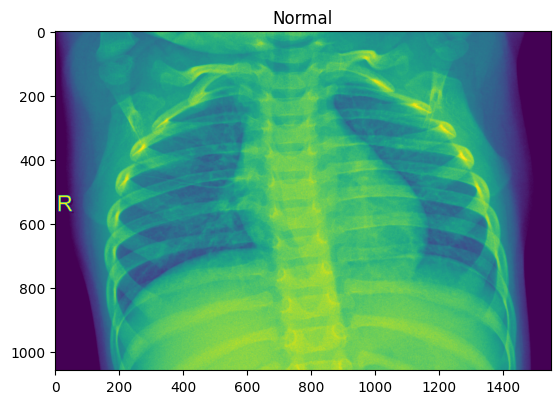

In [41]:
#print(os.listdir('/kaggle/input/labeled-chest-xray-images/chest_xray/train/NORMAL'))
image = plt.imread('/kaggle/input/labeled-chest-xray-images/chest_xray/train/NORMAL/NORMAL-705219-0001.jpeg')
plt.imshow(image)
plt.title('Normal')
print("Img Size: ",image.shape)

In [49]:
print(image.shape)

(1059, 1550)


In [53]:
def load_images():
    train_imgs= tf.keras.preprocessing.image_dataset_from_directory(
        '/kaggle/input/labeled-chest-xray-images/chest_xray/train',
        label_mode='binary'
    )
    test_imgs= tf.keras.preprocessing.image_dataset_from_directory(
        '/kaggle/input/labeled-chest-xray-images/chest_xray/test',
        label_mode='binary',
        shuffle=False
    )
    return train_imgs,test_imgs

In [54]:
for image_batch, labels_batch in load_image()[0]:
      print(image_batch.shape)
      print(labels_batch.shape)
      break

Found 5232 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
(32, 256, 256, 3)
(32, 1)


In [57]:
def data_gen():
    rescaling_layer = tf.keras.layers.Rescaling(1./255)

    AUTOTUNE = tf.data.AUTOTUNE
    #load images
    train_ds,test_ds = load_images() 
    
    train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
    test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)
    # normalizing images

    final_train_ds = train_ds.map(lambda img,label : (rescaling_layer(img),label))
    final_test_ds = test_ds.map(lambda img,label : (rescaling_layer(img),label))

    return final_train_ds,final_test_ds

final_train_ds,final_test_ds = data_gen()

Found 5232 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


In [62]:
image_batch, labels_batch = next(iter(final_train_ds))

In [66]:
print(image_batch.shape,labels_batch.shape)

(32, 256, 256, 3) (32, 1)


In [67]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(256,256,3)),
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 254, 254, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 32)        │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 28800)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,686,528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,732,673 (14.24 MB)

 Trainable params: 3,732,673 (14.24 MB)

 Non-trainable params: 0 (0.00 B)

In [70]:
model.compile(loss = 'binary_crossentropy',
             optimizer = tf.keras.optimizers.Adam(),
             metrics = ['accuracy'])

In [74]:
class Accuracy_callback(tf.keras.callbacks.Callback):
    def on_epoch_end(self,epochs,logs=None):
        if logs['accuracy'] >= 0.99:
            self.model.stop_training = True
            print("Model has reached 99% accuracy")

call = Accuracy_callback()

In [75]:
model.fit(
    final_train_ds,
    epochs = 5,
    validation_data=final_test_ds,
    callbacks=[call]
)

Epoch 1/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 415s 3s/step - accuracy: 0.9610 - loss: 0.1075 - val_accuracy: 0.8221 - val_loss: 0.5423
Epoch 2/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 403s 2s/step - accuracy: 0.9620 - loss: 0.1019 - val_accuracy: 0.8285 - val_loss: 0.6611
Epoch 3/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 411s 3s/step - accuracy: 0.9746 - loss: 0.0694 - val_accuracy: 0.7853 - val_loss: 0.9725
Epoch 4/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 432s 2s/step - accuracy: 0.9796 - loss: 0.0542 - val_accuracy: 0.8365 - val_loss: 0.8123
Epoch 5/5
164/164 ━━━━━━━━━━━━━━━━━━━━ 401s 2s/step - accuracy: 0.9874 - loss: 0.0327 - val_accuracy: 0.8061 - val_loss: 0.9976


In [76]:
model.save("V1_Pneumonia_detection.h5")
print('Model Saved!')

Model Saved!
